
CORRELATION ANALYSIS
CLOSE             1.000000
LTP               0.995469
VWAP              0.954114
HIGH              0.901336
LOW               0.896421
OPEN              0.780109
MOMENTUM_5        0.748243
PREV. CLOSE       0.698347
SMA_5             0.612713
EMA_10            0.593625
OPEN_TO_CLOSE     0.394353
RETURN            0.384484
SMA_10            0.198144
VOLATILITY_5      0.132759
SMA_20            0.016203
RANGE            -0.108276
VALUE            -0.205801
VOLUME           -0.236315
NO. OF  TRADES   -0.304199


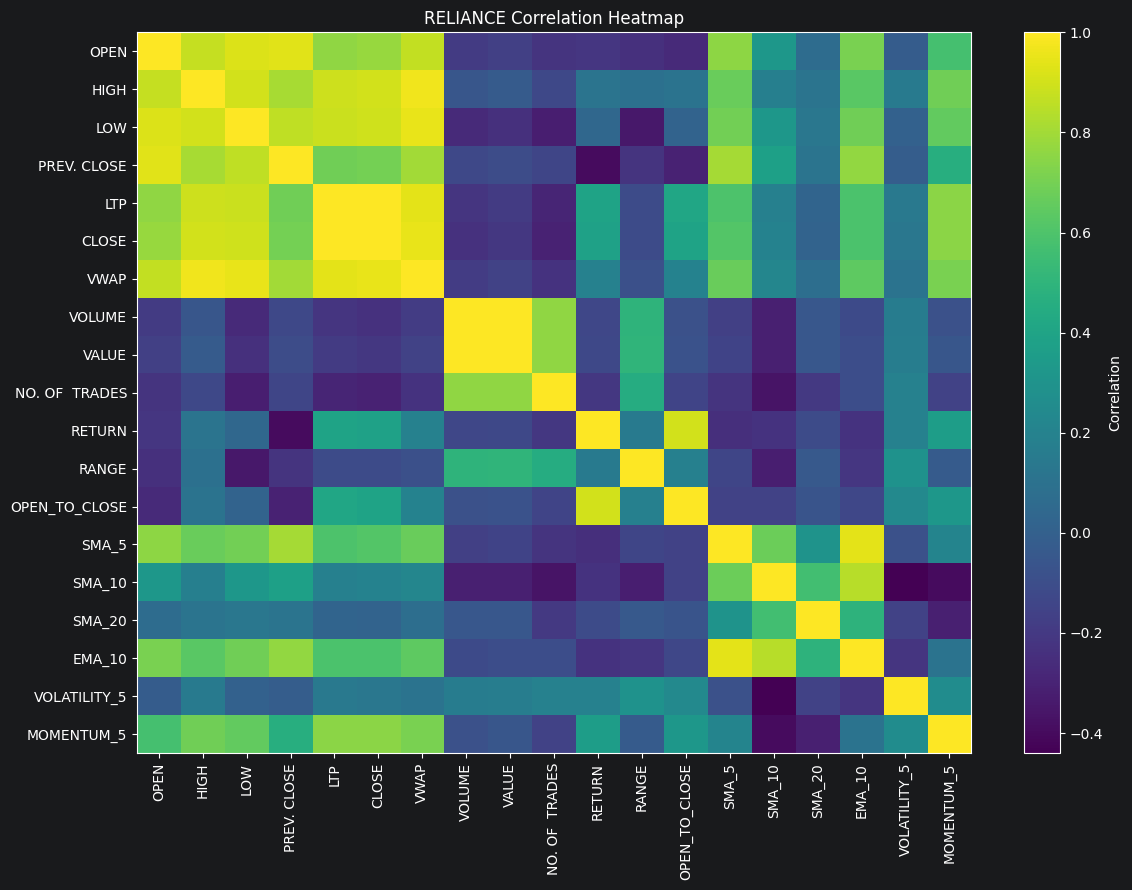


LINEAR REGRESSION
    Metric     Value
Train rows 36.000000
 Test rows 10.000000
       MAE 13.328061
      RMSE 16.653259
        R2 -0.389910

Feature coefficients:
     Feature  Coefficient
       CLOSE    -0.769419
        OPEN    -1.154140
        HIGH     0.569457
         LOW     0.972567
        VWAP     0.402008
      RETURN   661.806669
       RANGE    -0.403110
       SMA_5     1.220253
      SMA_10    -0.185242
      SMA_20    -1.889500
      EMA_10     0.041648
VOLATILITY_5   276.371138
  MOMENTUM_5   -16.968470


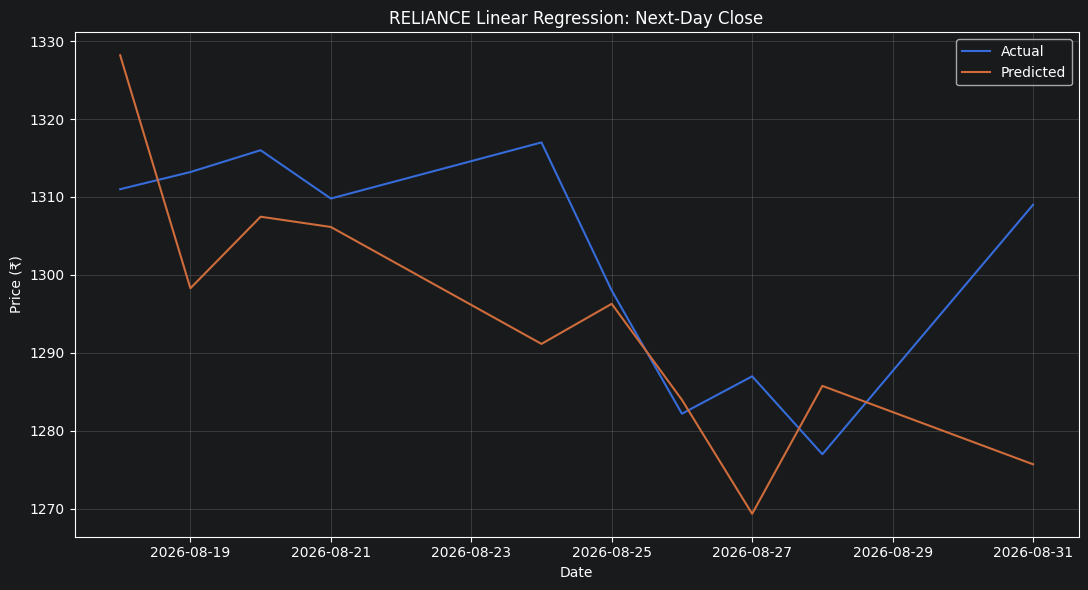

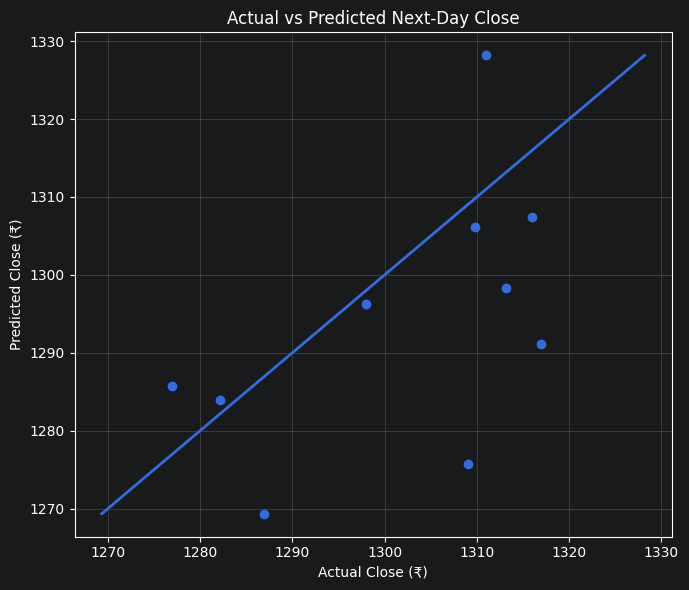


CLASSIFICATION: NEXT-DAY UP/DOWN
    Metric     Value
Train rows 36.000000
 Test rows 10.000000
  Accuracy  0.600000
 Precision  0.666667
    Recall  0.400000
        F1  0.500000

Classification report:
              precision    recall  f1-score   support

        DOWN       0.57      0.80      0.67         5
          UP       0.67      0.40      0.50         5

    accuracy                           0.60        10
   macro avg       0.62      0.60      0.58        10
weighted avg       0.62      0.60      0.58        10

Confusion matrix:
[[4 1]
 [3 2]]


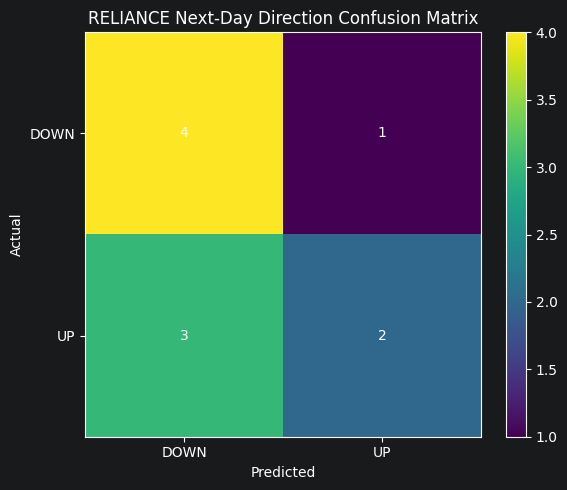

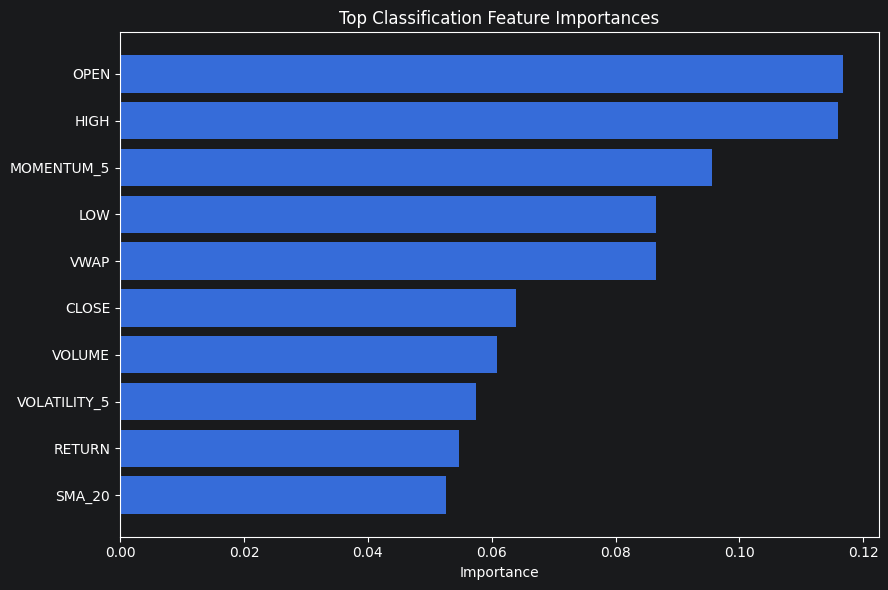


All outputs saved in: C:\Users\pravi\PycharmProjects\JupyterProject\Stock Data Analysis\reliance_analysis_output_2


In [2]:

# RELIANCE 3-Month Quantitative Analytics
# 1) Correlation
# 2) Linear Regression
# 3) Classification (next-day UP/DOWN)

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

CSV_FILE = "Quote-Equity-RELIANCE-EQ-01-06-2026-01-09-2026.csv"
OUTPUT_DIR = Path("reliance_analysis_output_2")
OUTPUT_DIR.mkdir(exist_ok=True)

def clean_number(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.replace("₹", "", regex=False),
        errors="coerce"
    )

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv(CSV_FILE)
df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True, errors="coerce")

numeric_cols = [
    "OPEN", "HIGH", "LOW", "PREV. CLOSE", "LTP", "CLOSE", "VWAP",
    "52 WEEK HIGH", "52 WEEK LOW", "VOLUME", "VALUE", "NO. OF  TRADES"
]
for col in numeric_cols:
    df[col] = clean_number(df[col])

df = df.dropna(subset=["DATE", "CLOSE"]).sort_values("DATE").reset_index(drop=True)

# Feature engineering
df["RETURN"] = df["CLOSE"].pct_change()
df["RANGE"] = df["HIGH"] - df["LOW"]
df["OPEN_TO_CLOSE"] = df["CLOSE"] - df["OPEN"]
df["SMA_5"] = df["CLOSE"].rolling(5).mean()
df["SMA_10"] = df["CLOSE"].rolling(10).mean()
df["SMA_20"] = df["CLOSE"].rolling(20).mean()
df["EMA_10"] = df["CLOSE"].ewm(span=10, adjust=False).mean()
df["VOLATILITY_5"] = df["RETURN"].rolling(5).std()
df["MOMENTUM_5"] = df["CLOSE"].pct_change(5)
df["TARGET_NEXT_DAY"] = (df["CLOSE"].shift(-1) > df["CLOSE"]).astype(int)

# ============================================================
# 1. CORRELATION
# ============================================================
correlation_cols = [
    "OPEN", "HIGH", "LOW", "PREV. CLOSE", "LTP", "CLOSE",
    "VWAP", "VOLUME", "VALUE", "NO. OF  TRADES",
    "RETURN", "RANGE", "OPEN_TO_CLOSE", "SMA_5",
    "SMA_10", "SMA_20", "EMA_10", "VOLATILITY_5", "MOMENTUM_5"
]
corr = df[correlation_cols].corr()
corr.to_csv(OUTPUT_DIR / "01_correlation_matrix.csv")

print("\n" + "="*65)
print("CORRELATION ANALYSIS")
print("="*65)
print(corr["CLOSE"].sort_values(ascending=False).to_string())

plt.figure(figsize=(12, 9))
plt.imshow(corr.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("RELIANCE Correlation Heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_correlation_heatmap.png", dpi=150)
plt.show()

# ============================================================
# 2. LINEAR REGRESSION - NEXT-DAY CLOSE
# ============================================================
# Features known at day t to predict Close at day t+1.
reg_features = [
    "CLOSE", "OPEN", "HIGH", "LOW", "VWAP",
    "RETURN", "RANGE", "SMA_5", "SMA_10", "SMA_20",
    "EMA_10", "VOLATILITY_5", "MOMENTUM_5"
]

reg_df = df[["DATE"] + reg_features].copy()
reg_df["TARGET"] = df["CLOSE"].shift(-1)
reg_df = reg_df.dropna().reset_index(drop=True)

# Time-ordered split
split = int(len(reg_df) * 0.80)
X_train = reg_df.loc[:split-1, reg_features]
y_train = reg_df.loc[:split-1, "TARGET"]
X_test = reg_df.loc[split:, reg_features]
y_test = reg_df.loc[split:, "TARGET"]

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

reg_results = pd.DataFrame({
    "Metric": ["Train rows", "Test rows", "MAE", "RMSE", "R2"],
    "Value": [len(X_train), len(X_test), mae, rmse, r2]
})
reg_results.to_csv(OUTPUT_DIR / "03_linear_regression_metrics.csv", index=False)

predictions = pd.DataFrame({
    "DATE": reg_df.loc[split:, "DATE"].values,
    "ACTUAL_NEXT_DAY_CLOSE": y_test.values,
    "PREDICTED_NEXT_DAY_CLOSE": y_pred
})
predictions.to_csv(OUTPUT_DIR / "04_linear_regression_predictions.csv", index=False)

coef = pd.DataFrame({
    "Feature": reg_features,
    "Coefficient": reg_model.coef_
})
coef.to_csv(OUTPUT_DIR / "05_linear_regression_coefficients.csv", index=False)

print("\nLINEAR REGRESSION")
print(reg_results.to_string(index=False))
print("\nFeature coefficients:")
print(coef.to_string(index=False))

plt.figure(figsize=(11, 6))
plt.plot(predictions["DATE"], predictions["ACTUAL_NEXT_DAY_CLOSE"], label="Actual")
plt.plot(predictions["DATE"], predictions["PREDICTED_NEXT_DAY_CLOSE"], label="Predicted")
plt.title("RELIANCE Linear Regression: Next-Day Close")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_linear_regression_actual_vs_predicted.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.title("Actual vs Predicted Next-Day Close")
plt.xlabel("Actual Close (₹)")
plt.ylabel("Predicted Close (₹)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_linear_regression_scatter.png", dpi=150)
plt.show()

# ============================================================
# 3. CLASSIFICATION - NEXT-DAY UP/DOWN
# ============================================================
# Use only information available on day t.
clf_features = [
    "CLOSE", "OPEN", "HIGH", "LOW", "VWAP", "VOLUME",
    "RETURN", "RANGE", "OPEN_TO_CLOSE",
    "SMA_5", "SMA_10", "SMA_20", "EMA_10",
    "VOLATILITY_5", "MOMENTUM_5"
]

clf_df = df[["DATE"] + clf_features + ["TARGET_NEXT_DAY"]].copy()
clf_df = clf_df.iloc[:-1].dropna().reset_index(drop=True)

split = int(len(clf_df) * 0.80)
X_train = clf_df.loc[:split-1, clf_features]
y_train = clf_df.loc[:split-1, "TARGET_NEXT_DAY"]
X_test = clf_df.loc[split:, clf_features]
y_test = clf_df.loc[split:, "TARGET_NEXT_DAY"]

# Random forest handles nonlinear relationships and mixed scales.
clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

classification_metrics = pd.DataFrame({
    "Metric": ["Train rows", "Test rows", "Accuracy", "Precision", "Recall", "F1"],
    "Value": [len(X_train), len(X_test), accuracy, precision, recall, f1]
})
classification_metrics.to_csv(OUTPUT_DIR / "08_classification_metrics.csv", index=False)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

classification_results = pd.DataFrame({
    "DATE": clf_df.loc[split:, "DATE"].values,
    "ACTUAL": y_test.values,
    "PREDICTED": y_pred
})
classification_results.to_csv(OUTPUT_DIR / "09_classification_results.csv", index=False)

feature_importance = pd.DataFrame({
    "Feature": clf_features,
    "Importance": clf_model.feature_importances_
}).sort_values("Importance", ascending=False)
feature_importance.to_csv(OUTPUT_DIR / "10_classification_feature_importance.csv", index=False)

print("\nCLASSIFICATION: NEXT-DAY UP/DOWN")
print(classification_metrics.to_string(index=False))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["DOWN", "UP"], zero_division=0))
print("Confusion matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks([0, 1], ["DOWN", "UP"])
plt.yticks([0, 1], ["DOWN", "UP"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RELIANCE Next-Day Direction Confusion Matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_classification_confusion_matrix.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 6))
top = feature_importance.head(10).sort_values("Importance")
plt.barh(top["Feature"], top["Importance"])
plt.title("Top Classification Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_classification_feature_importance.png", dpi=150)
plt.show()

print("\nAll outputs saved in:", OUTPUT_DIR.resolve())
